# Policy Comparison

In [16]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

from battery_sim.battery.battery import Battery
from battery_sim.agents.policies.rule_based import ThresholdPolicy
from battery_sim.agents.policies.continuous_probabilistic import ContinuousProbabilisticPolicy
from battery_sim.agents.policies.median_threshold import MedianThresholdPolicy, ProbabilisticMedianThresholdPolicy
from battery_sim.agents.policies.mppi import MPPIPolicy
from battery_sim.agents.policies.forecast_lp import ForecastLPPolicy
from battery_sim.agents.policies.oracle import OraclePolicy
from battery_sim.models.median_reversion import MedianReversionModel
from battery_sim.optimization.policy_optimizer import evaluate_full
from battery_sim.utils.plotting import plot_eval, plot_daily_revenue, plot_hourly_profile, compare_policies

In [2]:
# Load data
train_df = pd.read_csv('../data/NEM_NSW1_2025-01-01_2025-12-31_1h.csv')
test_df = pd.read_csv('../data/NEM_NSW1_2026-01-01_2026-03-01_1h.csv')

print(f'Train: {len(train_df)} rows ({train_df.iloc[0, 0]} to {train_df.iloc[-1, 0]})')
print(f'Test:  {len(test_df)} rows ({test_df.iloc[0, 0]} to {test_df.iloc[-1, 0]})')

Train: 8736 rows (2025-01-01 10:00:00 to 2025-12-31 09:00:00)
Test:  1416 rows (2026-01-01 10:00:00 to 2026-03-01 09:00:00)


In [3]:
# Battery config
# capacity is 200.0 mwh, charge rate is 100mw per hour
# very roughly based on New England 1 in NSW: https://gateway.icn.org.au/projects/14788/pg-14788
battery = Battery(
    capacity_mwh=200.0,
    max_charge_rate_mw=100,
    max_discharge_rate_mw=100,
    efficiency=0.9,
)

In [4]:
Q = 20
vals = np.quantile(train_df.price, q = [i/Q for i in range(1, Q)])
PARAM_GRID = {
    'buy_threshold':vals,
    'sell_threshold':vals,
}

# Pre-compute price series for RL feature extractors
all_prices = pd.concat([train_df, test_df], ignore_index=True)

## 1. Deterministic Threshold Policy

In [5]:
det_policy = ThresholdPolicy(
    buy_threshold=50.0,
    sell_threshold=200.0,
)

# Learn optimal thresholds on training data
det_policy.learn(
    train_data=train_df, 
    battery=battery, 
    num_iters=25, 
    window_len=24,
    param_grid=PARAM_GRID
)
print(f'Learned buy_threshold: {det_policy.buy_threshold}')
print(f'Learned sell_threshold: {det_policy.sell_threshold}')

Learned buy_threshold: 54.4225
Learned sell_threshold: 147.77833


## 3. Continuous Probabilistic Policy

In [6]:
cont_model = MedianReversionModel(window_days=30, interval_minutes=60)

cont_policy = ContinuousProbabilisticPolicy(
    model=cont_model,
    buy_threshold=50.0,
    sell_threshold=200.0,
)

cont_policy.learn(
    train_data=train_df,
    battery=battery,
    num_iters=10,
    window_len=24,
    param_grid=PARAM_GRID,
)
print(f'Learned buy_threshold: {cont_policy.buy_threshold}')
print(f'Learned sell_threshold: {cont_policy.sell_threshold}')

Learned buy_threshold: 91.780833
Learned sell_threshold: 168.311665


## 4. Median Threshold Policy

In [7]:
med_model = MedianReversionModel(window_days=30, interval_minutes=60)

med_policy = MedianThresholdPolicy(model=med_model, spread=50.0)
med_policy.learn(
    train_data=train_df,
    battery=battery,
    num_iters=10,
    window_len=24,
)
print(f"Best spread: {med_policy.spread}")

Best spread: 10


In [17]:
prob_med_model = MedianReversionModel(window_days=30, interval_minutes=60)
prob_med_policy = ProbabilisticMedianThresholdPolicy(
        model = prob_med_model,
        horizon = 6,
        n_trajectories = 50,
        spread = 50.0,
    )
prob_med_policy.learn(
    train_data=train_df,
    battery=battery,
    num_iters=10,
    window_len=24,
)

## 7. MPPI (Model Predictive Path Integral) Policy

In [8]:
mppi_model = MedianReversionModel(window_days=30, interval_minutes=60)
mppi_policy = MPPIPolicy(
    model=mppi_model,
    battery=battery,
    horizon=12,
    n_samples=100,
    n_trajectories=100,
)

mppi_policy.learn(
    train_data=train_df,
    battery=battery,
    num_iters=25,
    window_len=24,
)
print(f'Tuned noise_sigma: {mppi_policy.noise_sigma}')
print(f'Tuned temperature: {mppi_policy.temperature}')

Tuned noise_sigma: 0.2
Tuned temperature: 0.75


## 8. Forecast LP Policy (MPC with Model Forecasts)

In [9]:
forecast_lp_model = MedianReversionModel(window_days=30, interval_minutes=60)
forecast_lp_policy = ForecastLPPolicy(
    model=forecast_lp_model,
    battery=battery,
    horizon=12,
    interval_minutes=60,
)

forecast_lp_policy.learn(
    train_data=train_df,
    battery=battery,
)
print("Forecast LP policy trained")

Forecast LP policy trained


## 9. Oracle (Perfect Foresight)

In [10]:
oracle = OraclePolicy(price_data=test_df, battery=battery)
print(f'Oracle solved LP with {len(test_df) - 1} tradeable steps')

Oracle solved LP with 1415 tradeable steps


## 10. Evaluate on Test Set

In [19]:
# Re-fit models on train data before test evaluation
mppi_model.fit(train_df)
cont_model.fit(train_df)
forecast_lp_model.fit(train_df)
med_model.fit(train_df)

det_eval = evaluate_full('Deterministic Threshold', det_policy, test_df, battery)
cont_eval = evaluate_full('Continuous Probabilistic', cont_policy, test_df, battery)
med_eval = evaluate_full('Median Threshold', med_policy, test_df, battery)
mppi_eval = evaluate_full('MPPI', mppi_policy, test_df, battery)
forecast_lp_eval = evaluate_full('Forecast LP', forecast_lp_policy, test_df, battery)
oracle_eval = evaluate_full('Oracle', oracle, test_df, battery)
prob_med_eval = evaluate_full('Probabilistic Median Threshold', prob_med_policy, test_df, battery)

all_evals = [det_eval, cont_eval, prob_med_eval, med_eval, mppi_eval, forecast_lp_eval, oracle_eval]
for e in all_evals:
    print(e.summary())
    print()

Deterministic Threshold:
  Cumulative revenue: $624,015.26
  Mean daily revenue: $10,400.25 (+/- $31,165.89)
  Total steps: 1415

Continuous Probabilistic:
  Cumulative revenue: $766,276.12
  Mean daily revenue: $12,771.27 (+/- $60,524.31)
  Total steps: 1415

Probabilistic Median Threshold:
  Cumulative revenue: $675,839.66
  Mean daily revenue: $11,263.99 (+/- $27,507.50)
  Total steps: 1415

Median Threshold:
  Cumulative revenue: $719,017.75
  Mean daily revenue: $11,983.63 (+/- $28,456.42)
  Total steps: 1415

MPPI:
  Cumulative revenue: $950,458.77
  Mean daily revenue: $15,840.98 (+/- $117,984.94)
  Total steps: 1415

Forecast LP:
  Cumulative revenue: $964,507.89
  Mean daily revenue: $16,075.13 (+/- $56,958.87)
  Total steps: 1415

Oracle:
  Cumulative revenue: $2,489,342.08
  Mean daily revenue: $41,489.03 (+/- $133,334.45)
  Total steps: 1415



## 11. Hourly Profiles

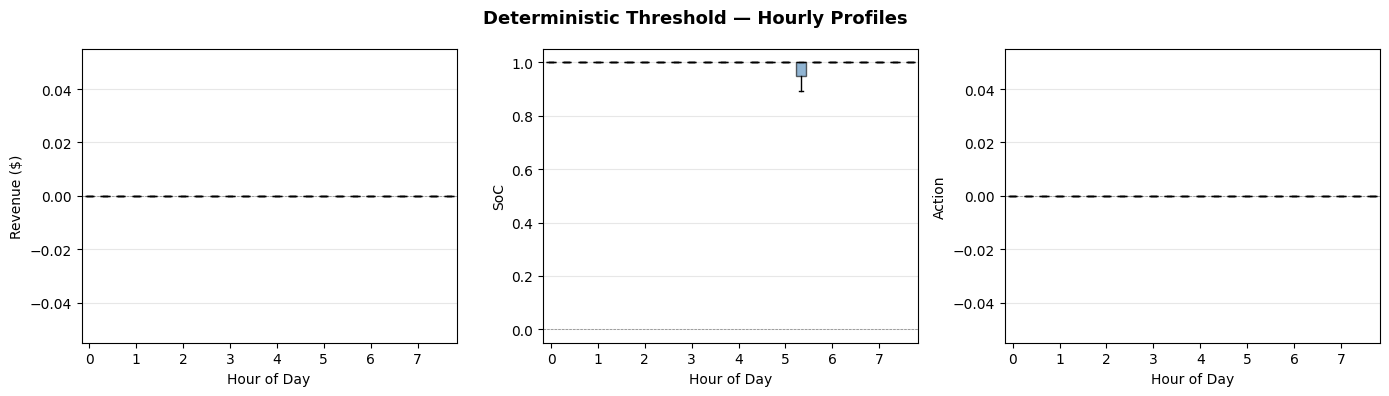

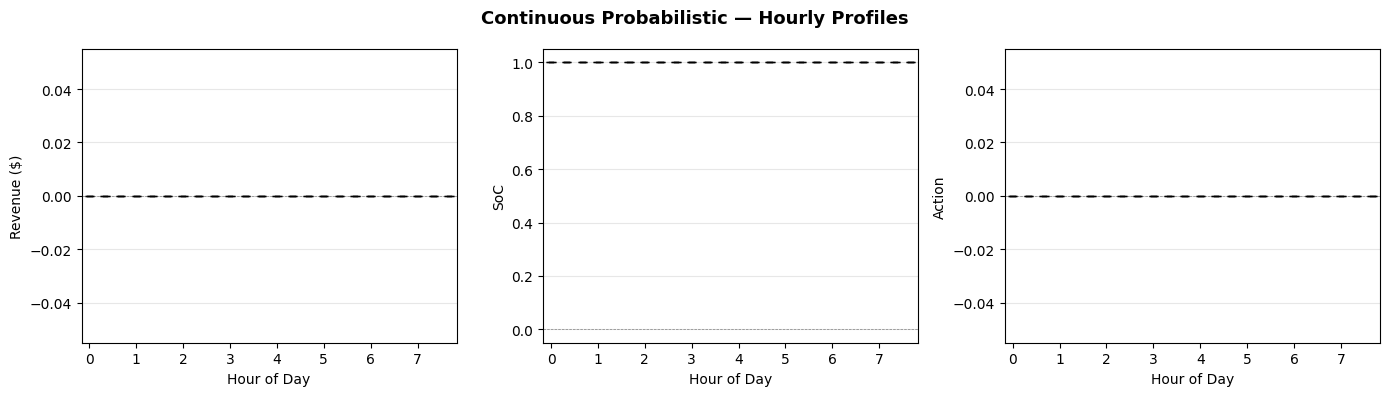

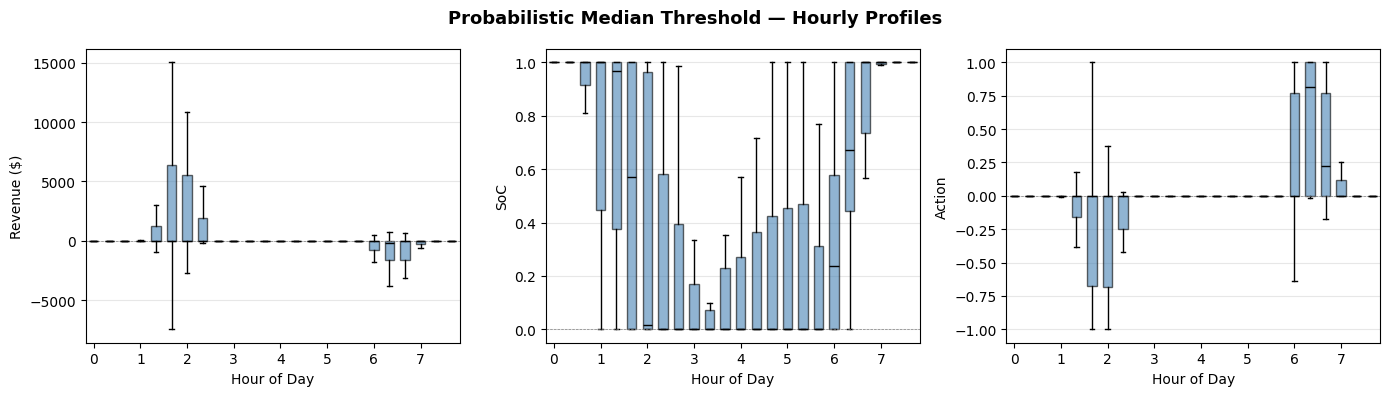

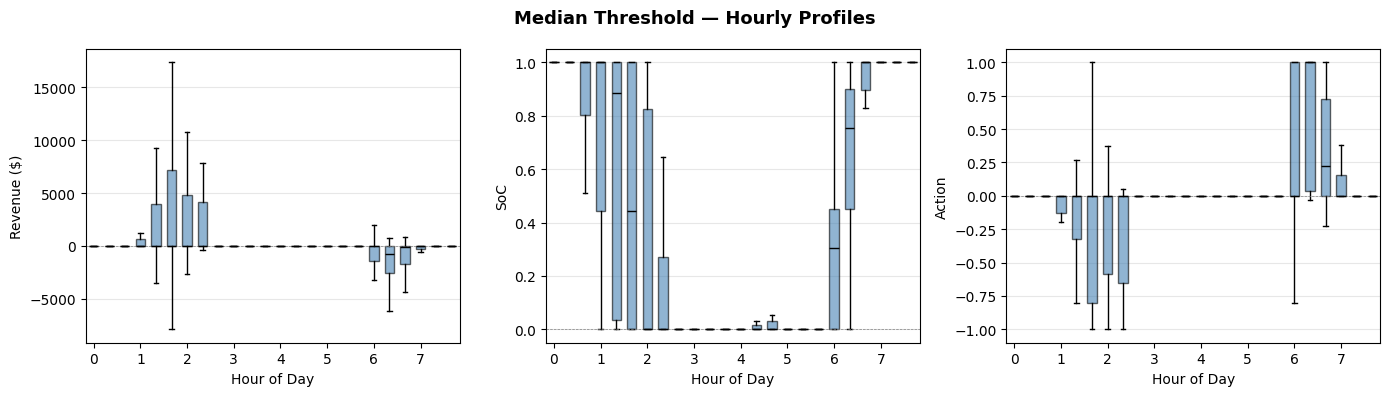

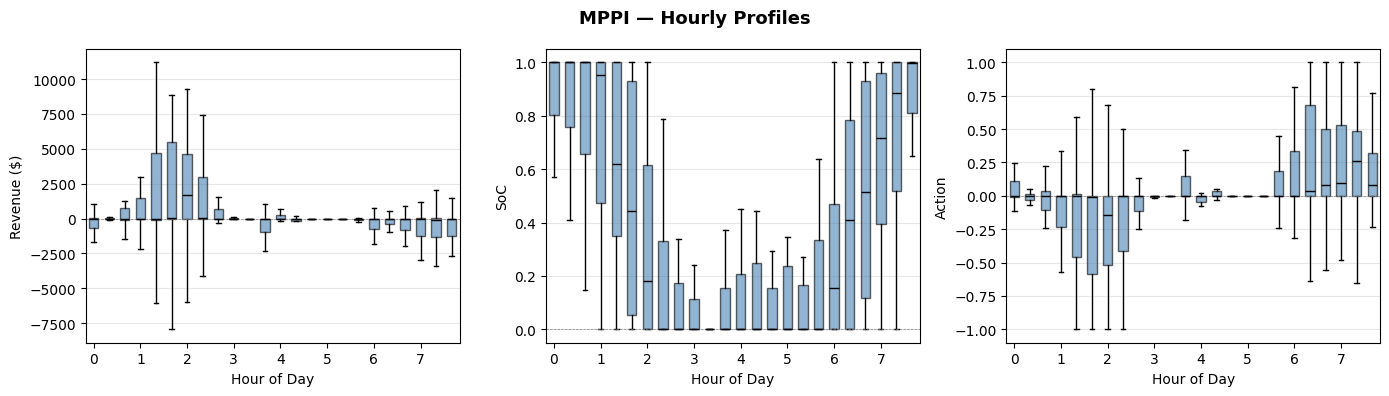

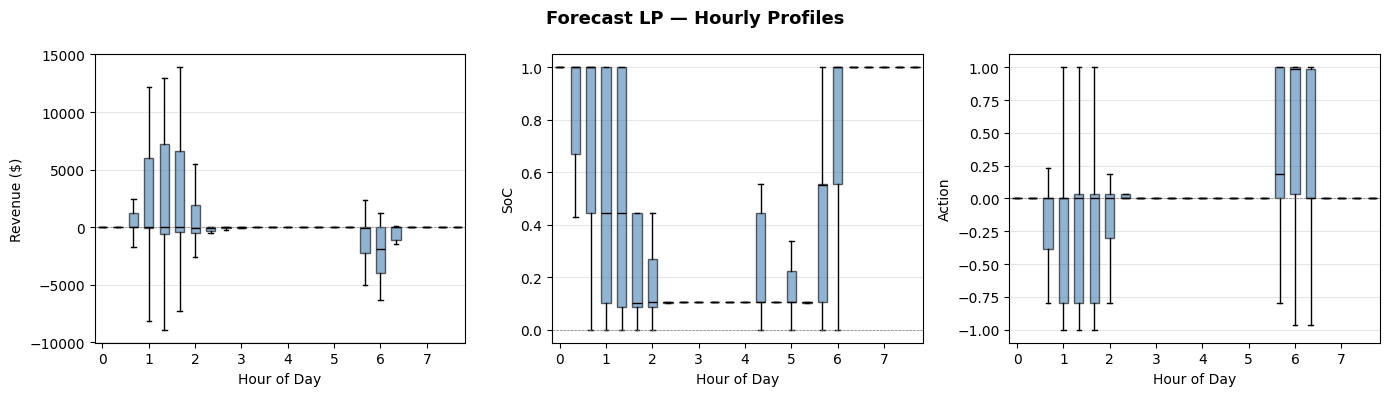

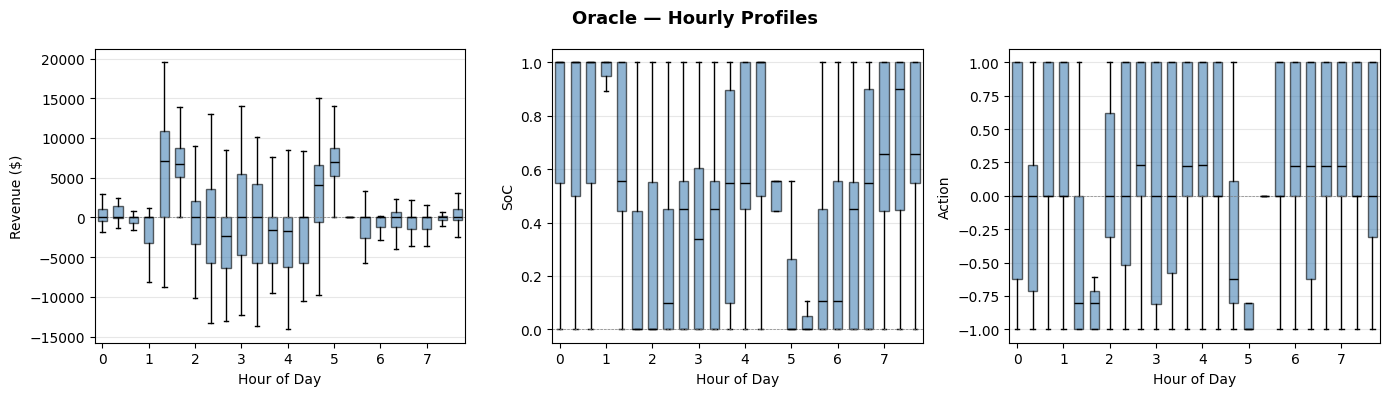

In [21]:
for e in all_evals:
    plot_hourly_profile(e)
    plt.show()

## 12. Detailed Time Series

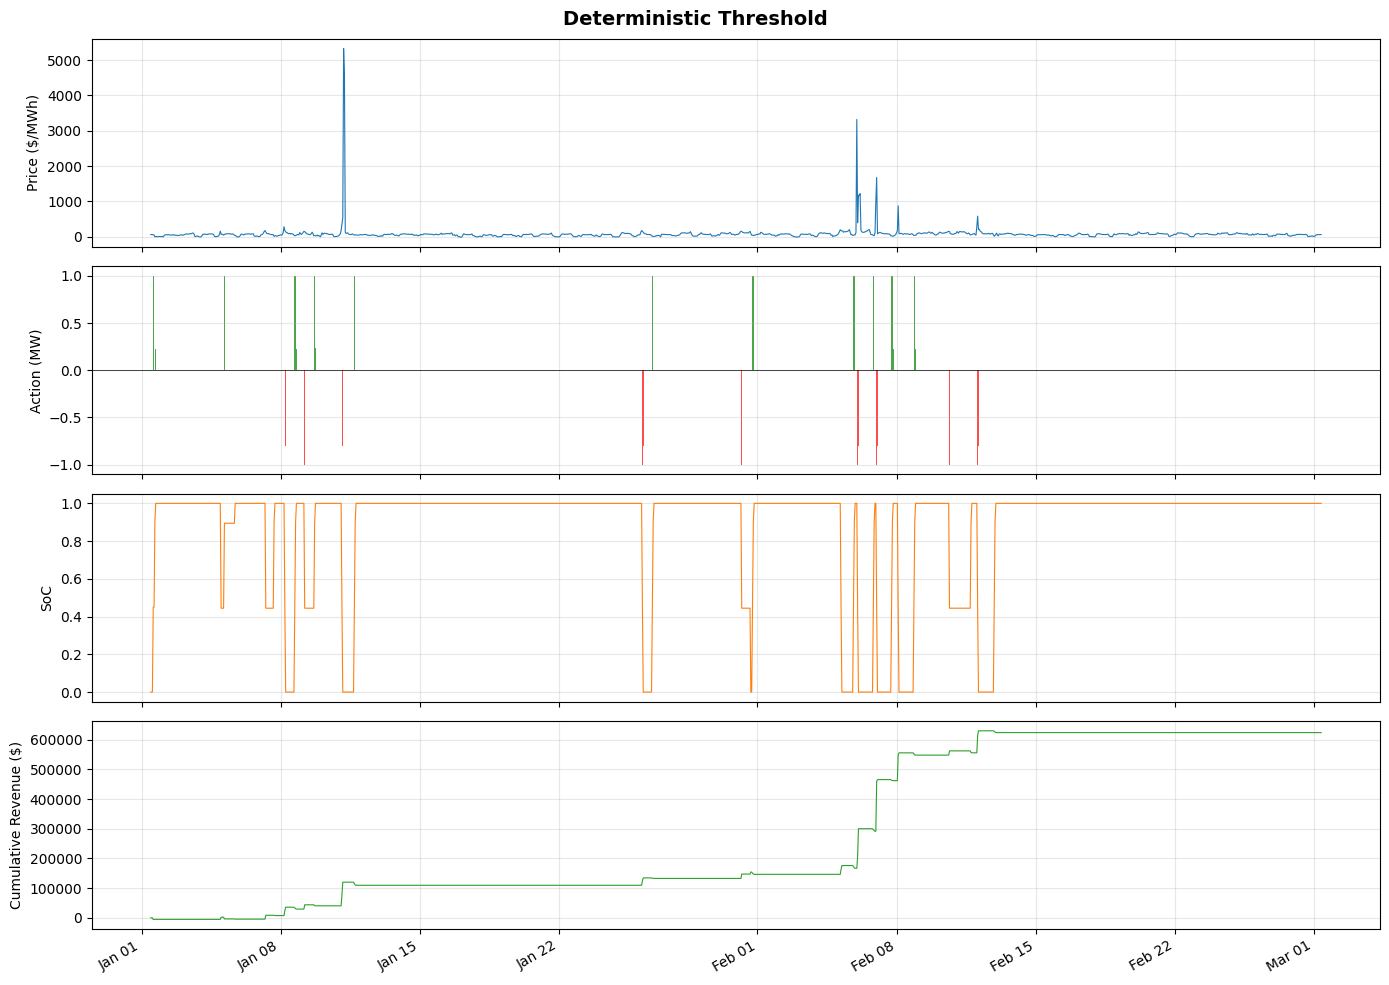

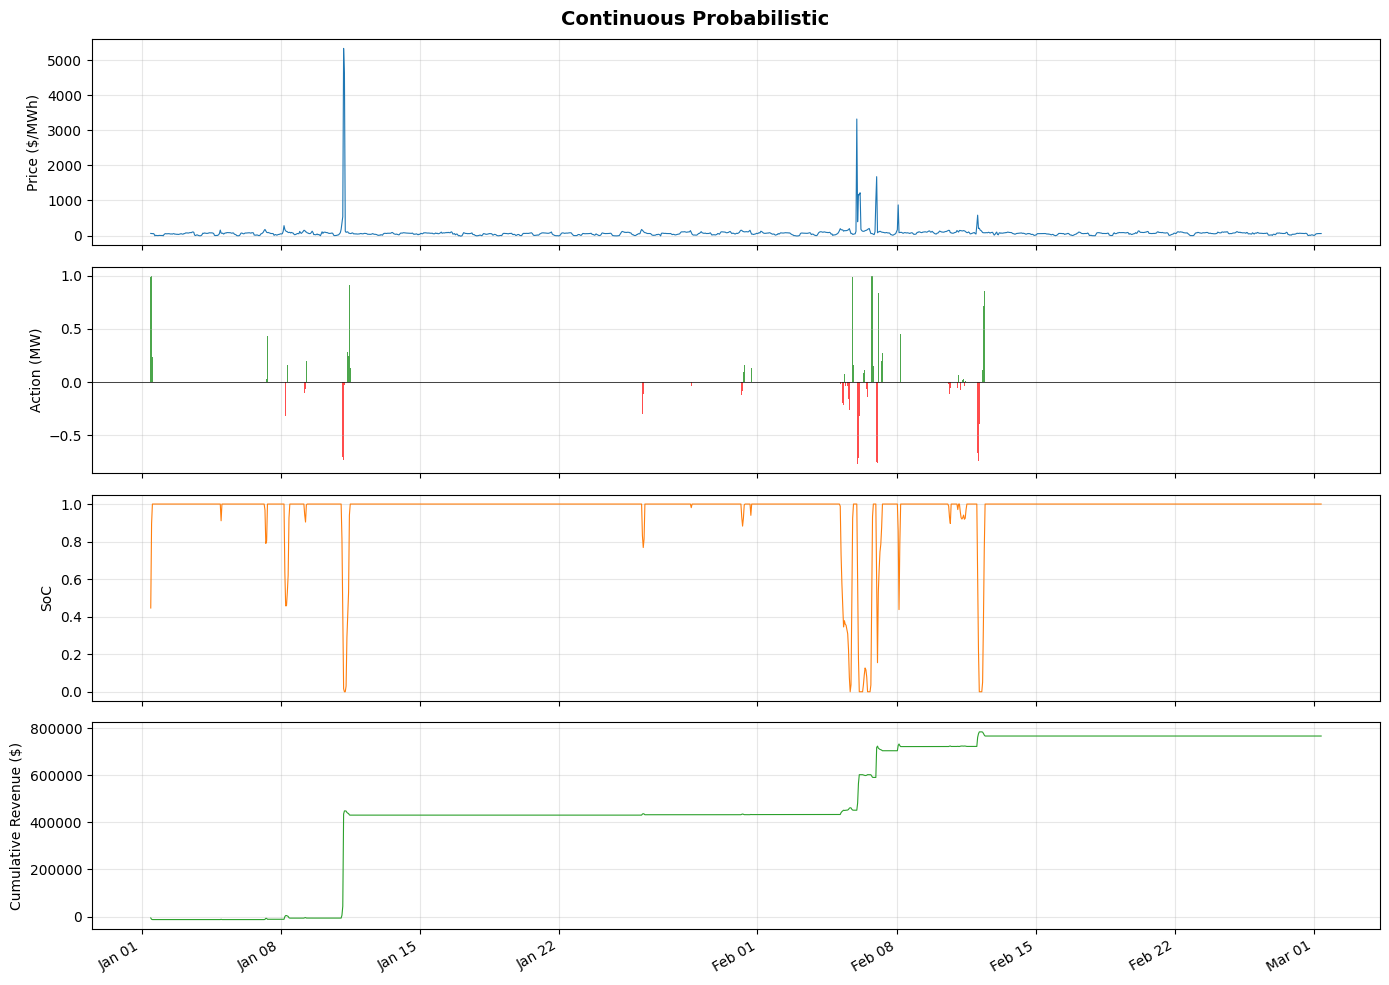

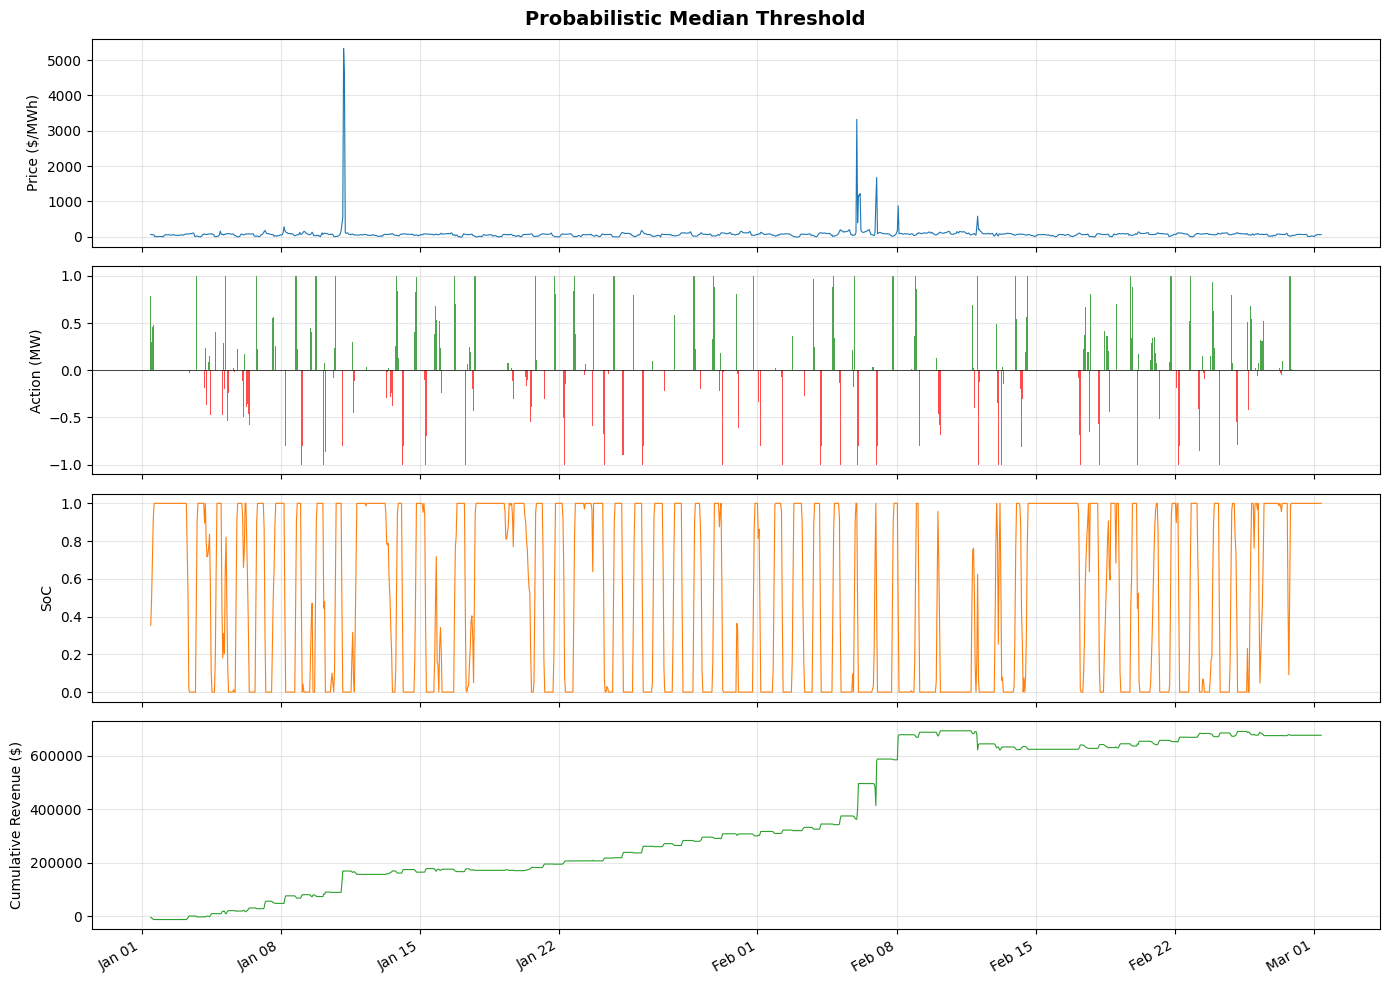

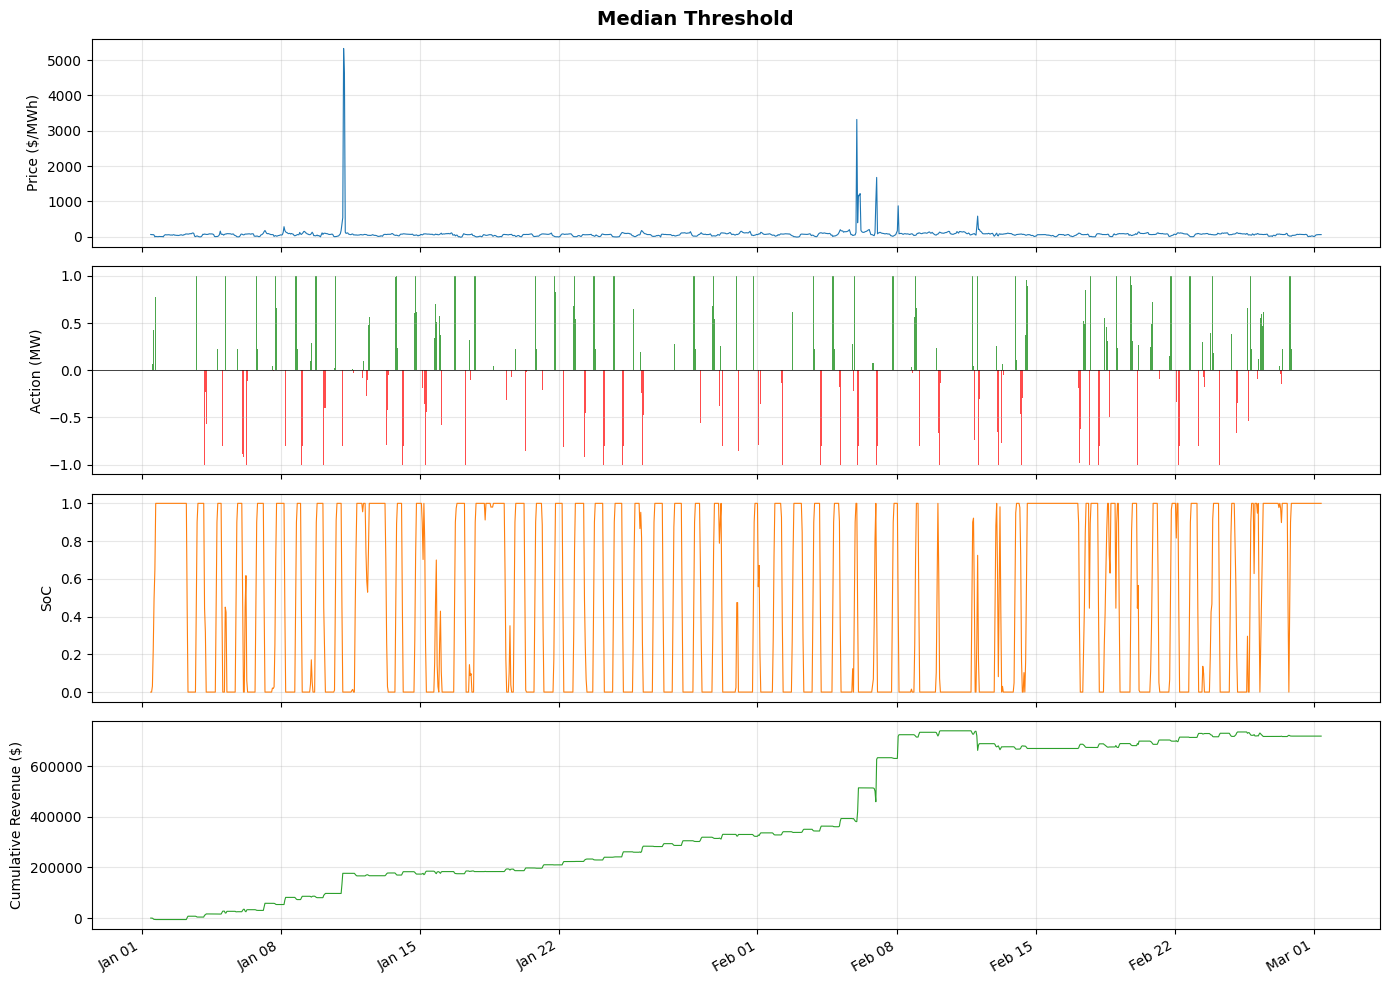

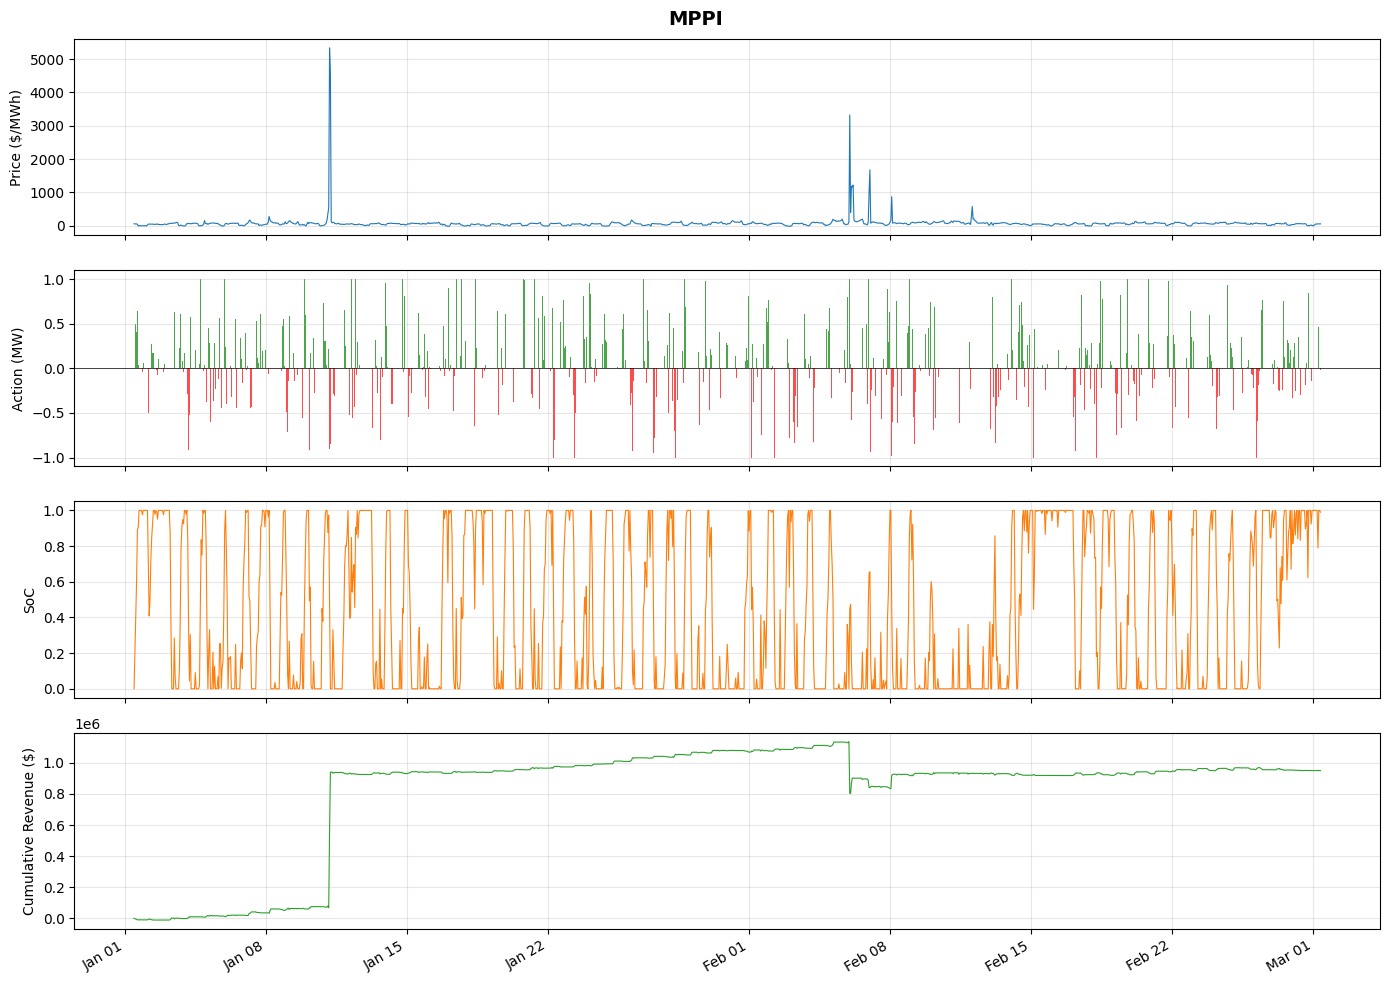

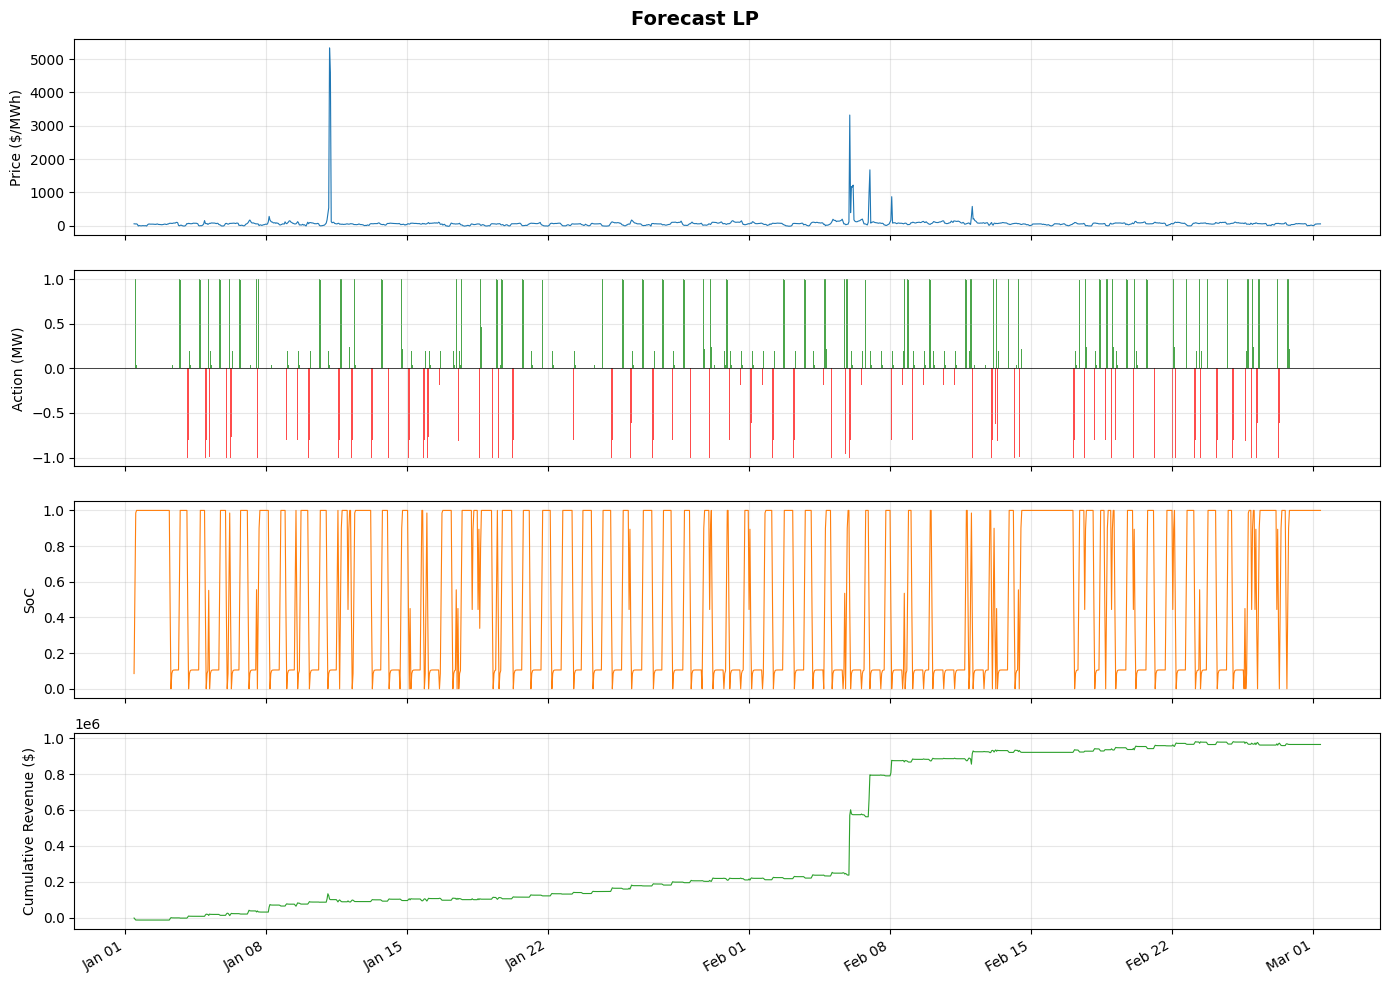

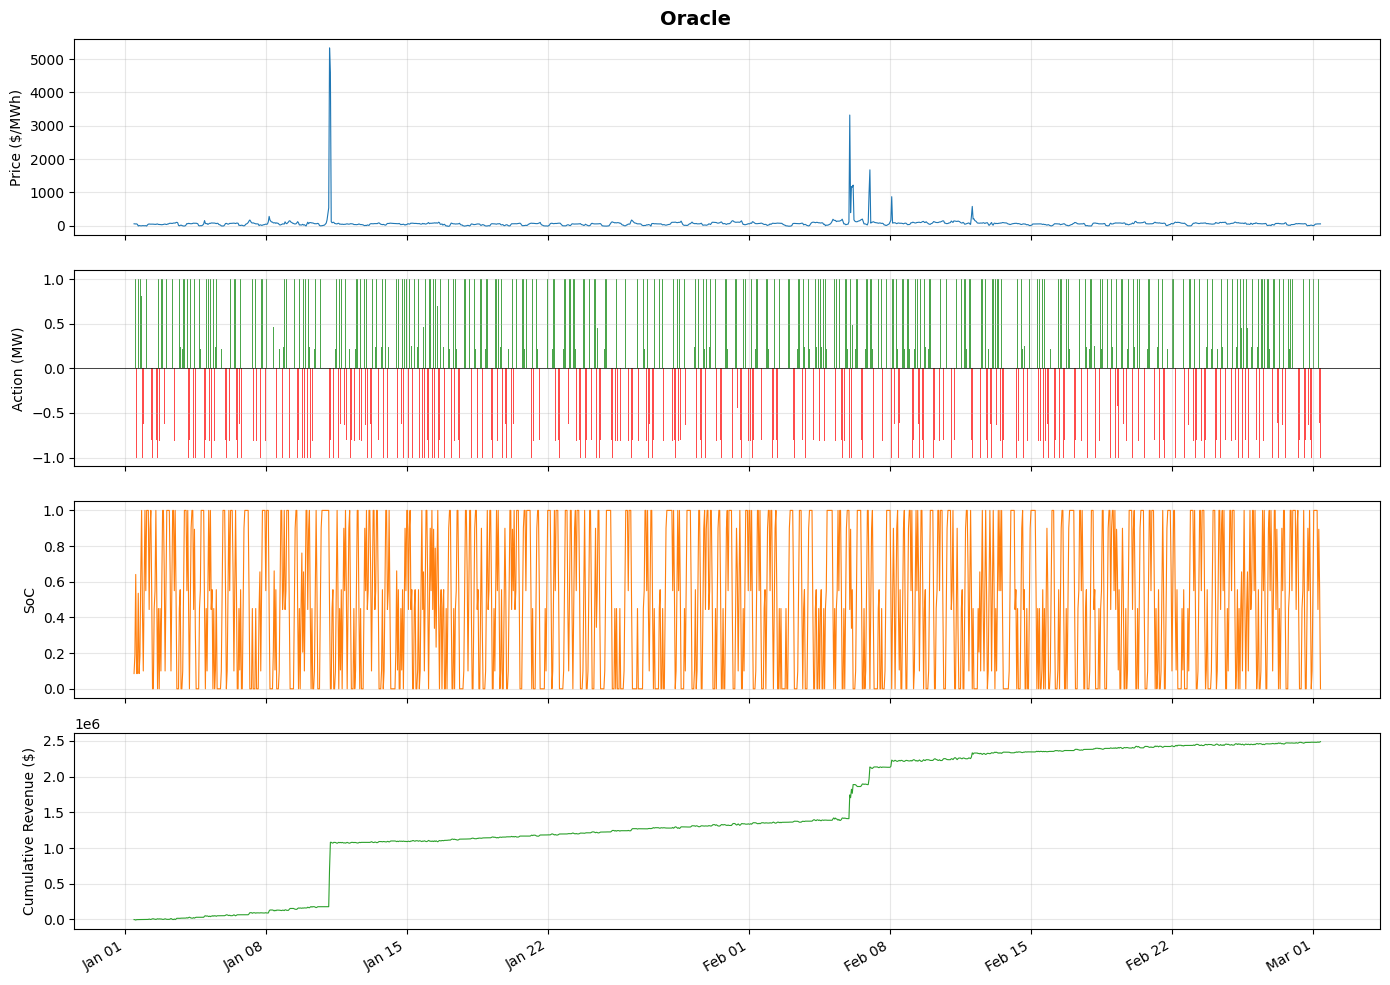

In [20]:
for e in all_evals:
    plot_eval(e)
    plt.show()

## 13. Policy Comparison

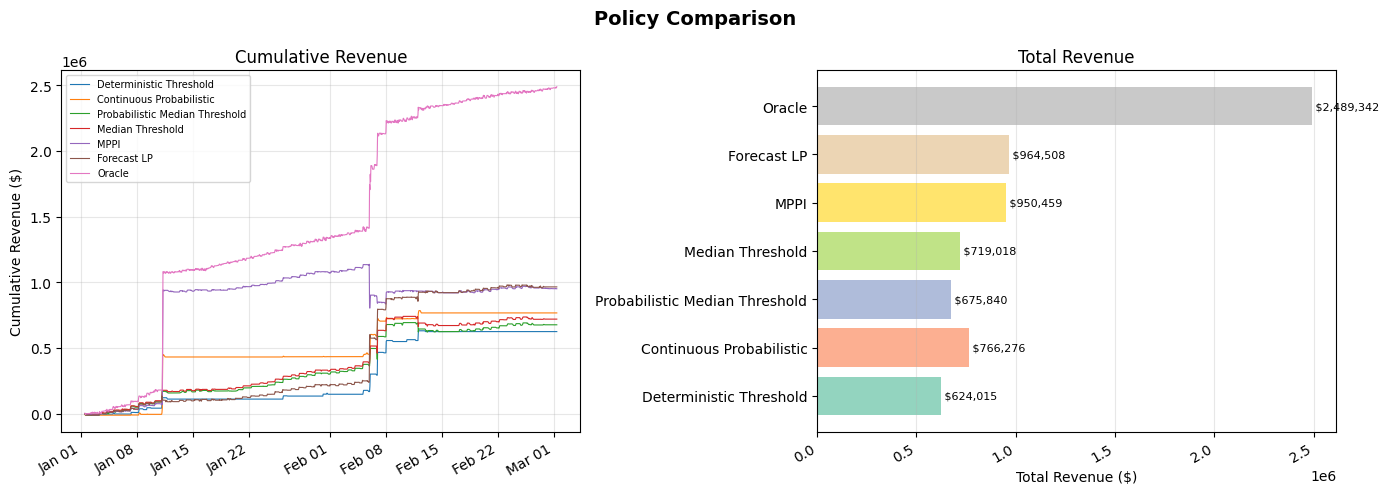

In [22]:
compare_policies(all_evals)
plt.show()